In [1]:

from QHED import *

# Quantum Hadamard Edge Detection
To implement QHED, our first step is to encode a given image into a quantum state. We use amplitude encoding for this so QuantumCircuit.initialize is a suitable method for encoding our image. However, some pre-processing may be required depending on image size (i.e. downscalling or image batching).

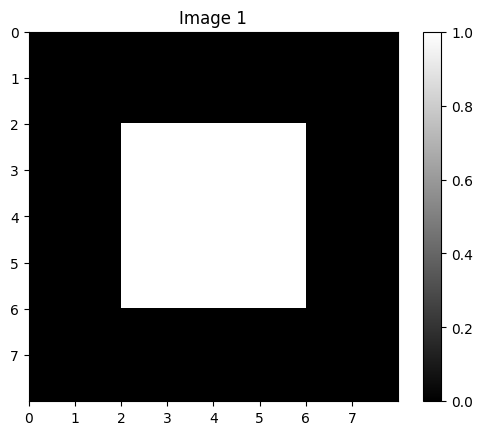

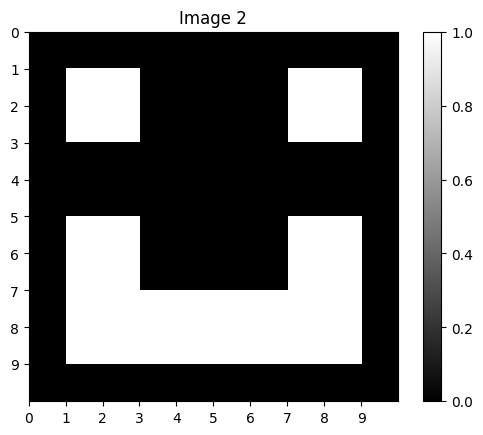

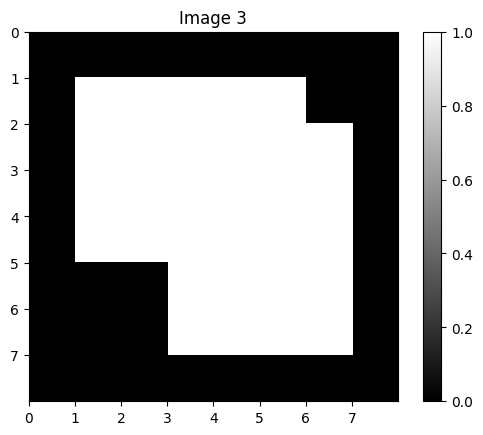

In [2]:
img1 = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 1, 1, 1, 1, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [0, 0, 0, 0, 0, 0, 0, 0]])

img2 = np.array([[0, 0, 0, 0, 0, 0, 0, 0,0,0],
                [0, 1, 1, 0, 0, 0, 0,1,1,0],
                [0, 1, 1, 0, 0, 0, 0,1,1,0],
                [0, 0, 0, 0, 0, 0, 0, 0,0,0],
                [0, 0, 0, 0, 0, 0, 0, 0,0,0],
                [0, 1, 1, 0, 0, 0, 0, 1,1,0],
                [0, 1, 1, 0, 0, 0, 0, 1,1,0],
                [0, 1, 1, 1, 1, 1, 1, 1,1,0],
                [0, 1, 1, 1, 1, 1, 1, 1,1,0],
                [0, 0, 0, 0, 0, 0, 0, 0,0,0]])

img3 = np.array([[0, 0, 0, 0, 0, 0, 0, 0],
                  [0, 1, 1, 1, 1, 1, 0, 0],
                  [0, 1, 1, 1, 1, 1, 1, 0],
                  [0, 1, 1, 1, 1, 1, 1, 0],
                  [0, 1, 1, 1, 1, 1, 1, 0],
                  [0, 0, 0, 1, 1, 1, 1, 0],
                  [0, 0, 0, 1, 1, 1, 1, 0],
                  [0, 0, 0, 0, 0, 0, 0, 0]])


# plot image function

def plot_image(Image, title):
    plt.title(title)
    plt.xticks(range(Image.shape[0]))
    plt.yticks(range(Image.shape[1]))
    plt.imshow(Image, extent=[  0,Image.shape[0], Image.shape[1],0,], cmap='gray', vmin=0, vmax=1)
    plt.colorbar()
    plt.show()
    
plot_image(img1, 'Image 1')
plot_image(img2, 'Image 2')
plot_image(img3, 'Image 3')

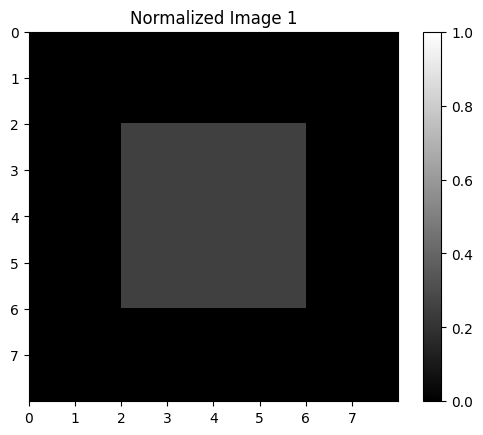

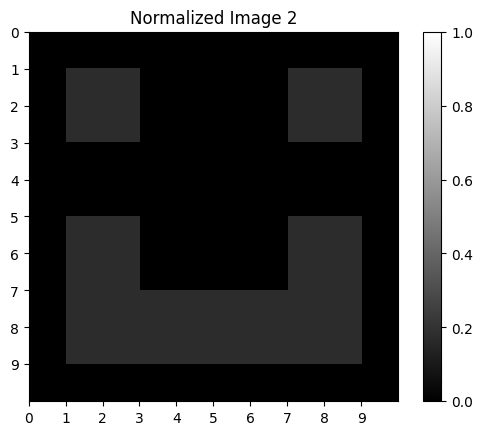

In [3]:
'''def normalize_image(image):
    image64 = np.asarray(image, dtype=np.float64)
    shape = image64.shape
    flat = image64.flatten()
    norm = np.linalg.norm(flat)
    if norm == 0:
        raise ValueError('Input image has zero norm; cannot encode amplitudes.')
    norm_image = flat / norm
    return norm_image.reshape(shape)
'''
norm_img1 = normalize_image(img1)
norm_img2 = normalize_image(img2)

plot_image(norm_img1, 'Normalized Image 1')
plot_image(norm_img2, 'Normalized Image 2')

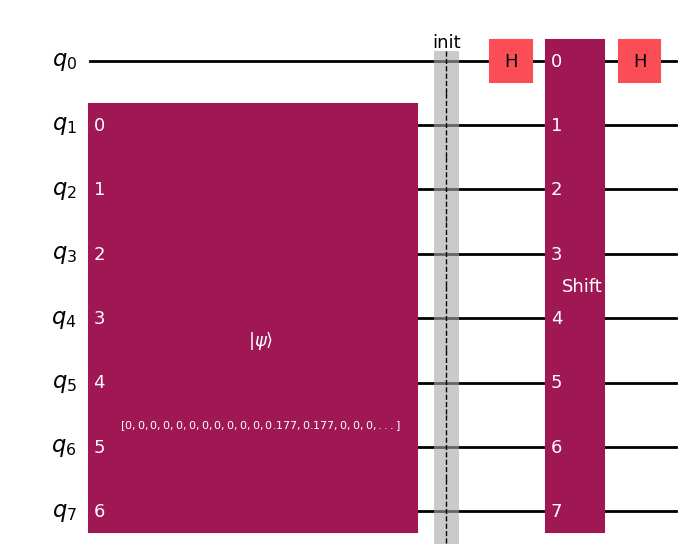

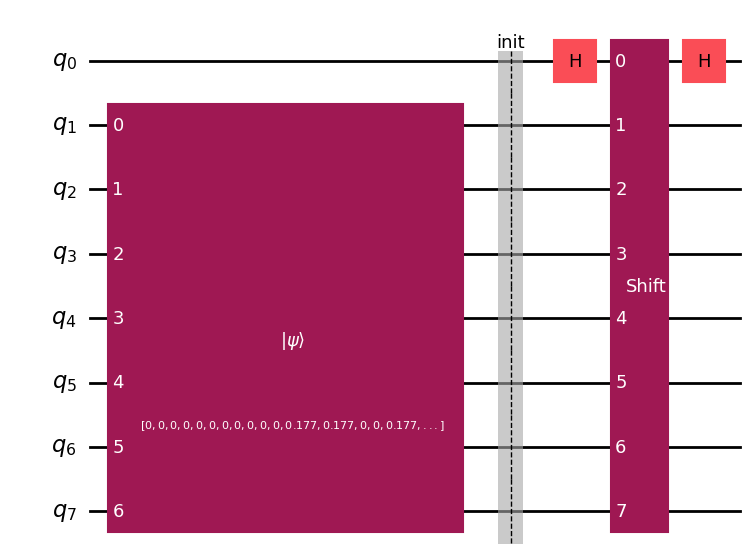

statevector mode result count: 2


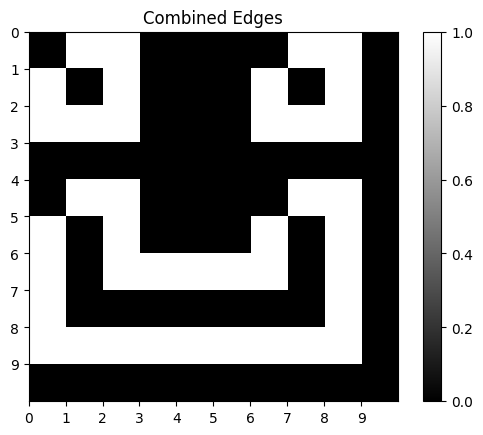

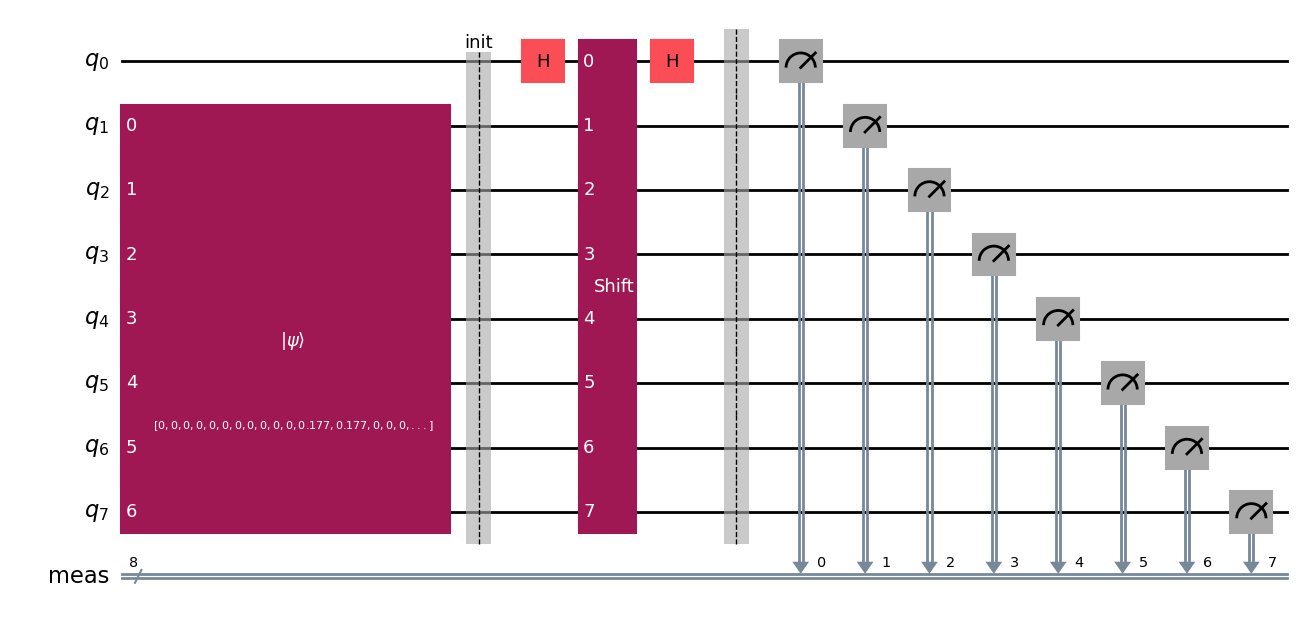

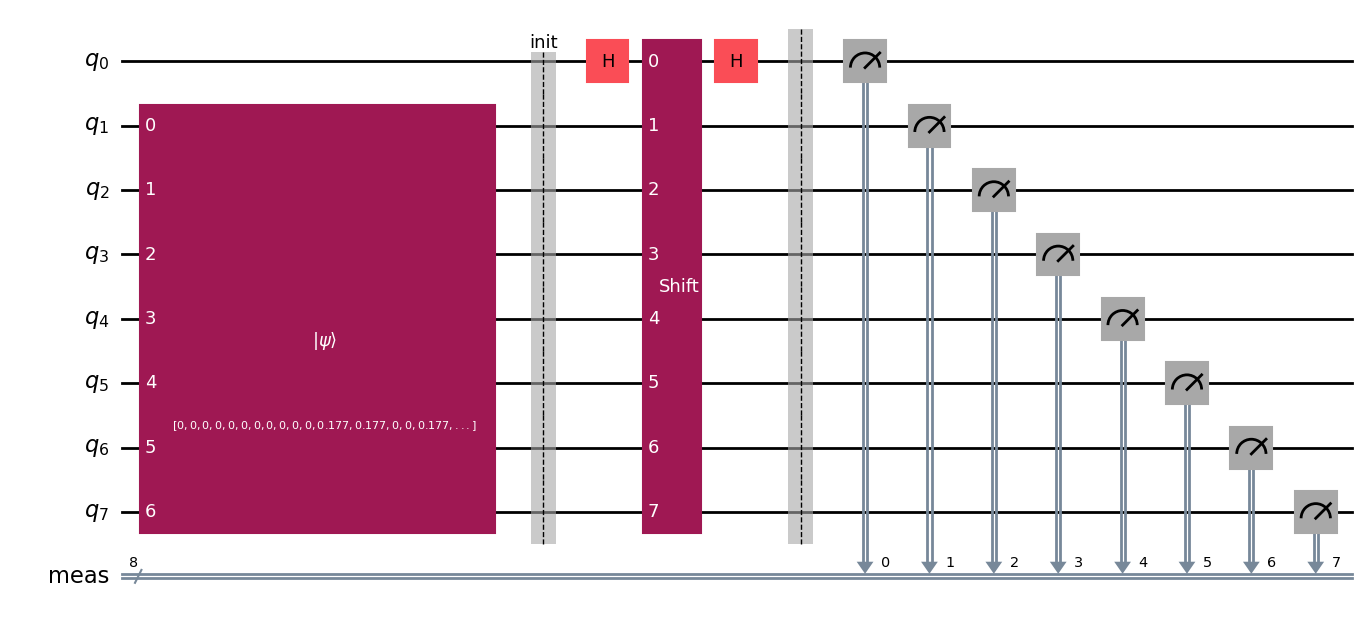

measurement mode result count: 2


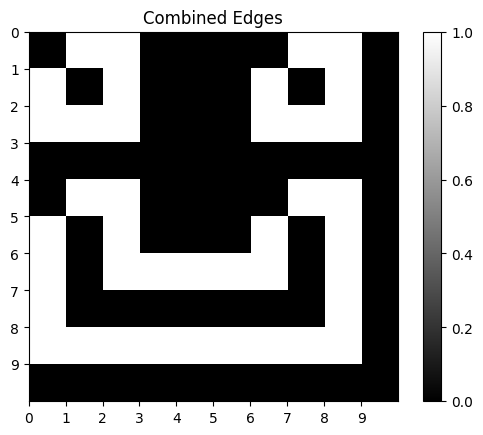

In [4]:
# TESTING
qhed1 = QHED(img2, measure=False, display=True)
print('statevector mode result count:', len(qhed1.results))
qhed1.plot_results()

# test with measurement
qhed2 = QHED(img2, measure=True, display=True, shots=1024)
print('measurement mode result count:', len(qhed2.results))
qhed2.plot_results()


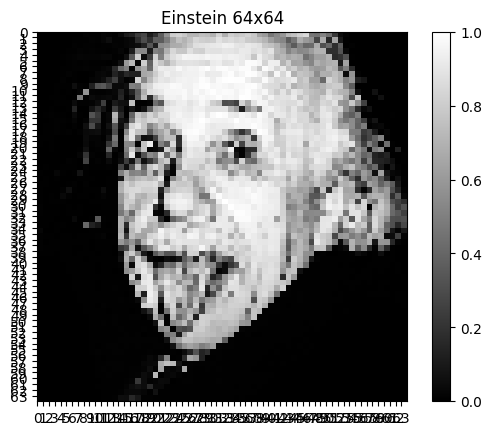

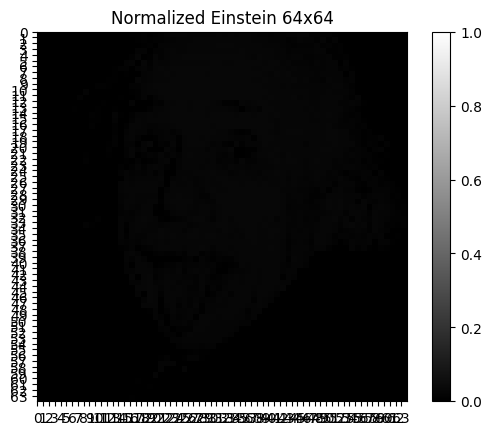

Einstein statevector mode result count: 2


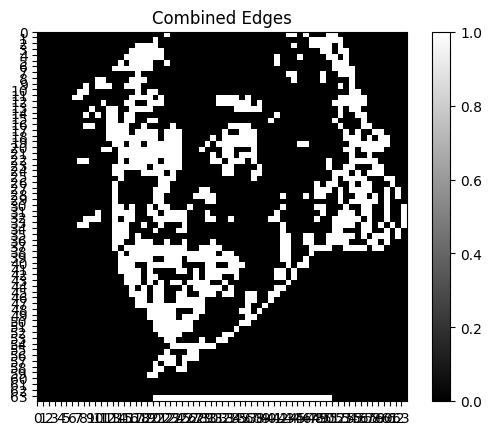

In [5]:
# try on Einstein image (downsampled to keep statevector simulation tractable)
img = plt.imread('einstein.png')
img_gray = np.mean(img[..., :3], axis=2) if img.ndim == 3 else img
img_gray = np.asarray(img_gray, dtype=np.float64)

# Resize with index mapping (no extra dependency needed).
target_h, target_w = 64, 64
r_idx = np.linspace(0, img_gray.shape[0] - 1, target_h).astype(int)
c_idx = np.linspace(0, img_gray.shape[1] - 1, target_w).astype(int)
img_small = img_gray[np.ix_(r_idx, c_idx)]

plot_image(img_small, 'Einstein 64x64')

norm_img = normalize_image(img_small)
plot_image(norm_img, 'Normalized Einstein 64x64')

# Important: run QHED on normalized, downsampled data.
qhed_einstein = QHED(norm_img, measure=False, display=False)
print('Einstein statevector mode result count:', len(qhed_einstein.results))
qhed_einstein.plot_results()

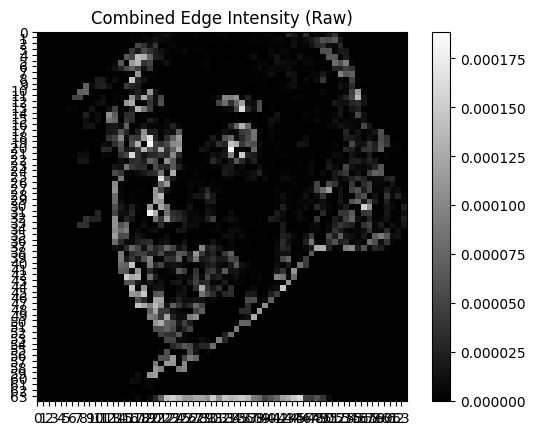

In [6]:
qhed_einstein.plot_raw_results()